# Ravdess data exploration
# Goal:understand the dataset's real characteristics (class balance,actor/gender balance,audio duration,silence,quality) before tuning the model further

In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

from src.config import (
    RAW_DATA_DIR,
    METADATA_CSV,
    EMOTION_MAP,
    SAMPLE_RATE,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(10,5)

# Load Metadata

In [2]:
if not os.path.exists(METADATA_CSV):
    raise FileNotFoundError("metadat.csv not found. Run src/data_parser.py first.")

df=pd.read_csv(METADATA_CSV)
print(f"Total files:{len(df)}")
df.head()

Total files:1440


,filename,filepath,modality_code,modality,vocal_channel_code,vocal_channel,emotion_code,emotion,intensity_code,intensity,statement_code,statement,repetition_code,repetition,actor_code,actor_id,gender
0,03-01-01-01-01-01-01.wav,C:\Users\mohit\Emotional Recognition from Spee...,3,audio_only,1,speech,1,neutral,1,normal,1,Kids are talking by the door,1,1st_repetition,1,1,male
1,03-01-01-01-01-02-01.wav,C:\Users\mohit\Emotional Recognition from Spee...,3,audio_only,1,speech,1,neutral,1,normal,1,Kids are talking by the door,2,2nd_repetition,1,1,male
2,03-01-01-01-02-01-01.wav,C:\Users\mohit\Emotional Recognition from Spee...,3,audio_only,1,speech,1,neutral,1,normal,2,Dogs are sitting by the door,1,1st_repetition,1,1,male
3,03-01-01-01-02-02-01.wav,C:\Users\mohit\Emotional Recognition from Spee...,3,audio_only,1,speech,1,neutral,1,normal,2,Dogs are sitting by the door,2,2nd_repetition,1,1,male
4,03-01-02-01-01-01-01.wav,C:\Users\mohit\Emotional Recognition from Spee...,3,audio_only,1,speech,2,calm,1,normal,1,Kids are talking by the door,1,1st_repetition,1,1,male


## 2.Basic overview

In [3]:
print("Shape:",df.shape)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nUnique actors:",df['actor_id'].nunique())
print("Unique emotions:",df['emotion'].nunique())
print("Unique statements:",df['statement'].nunique())

Shape: (1440, 17)

Missing values per column:
filename              0
filepath              0
modality_code         0
modality              0
vocal_channel_code    0
vocal_channel         0
emotion_code          0
emotion               0
intensity_code        0
intensity             0
statement_code        0
statement             0
repetition_code       0
repetition            0
actor_code            0
actor_id              0
gender                0
dtype: int64

Unique actors: 24
Unique emotions: 8
Unique statements: 2


# 3.Emotion class distribution

emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64


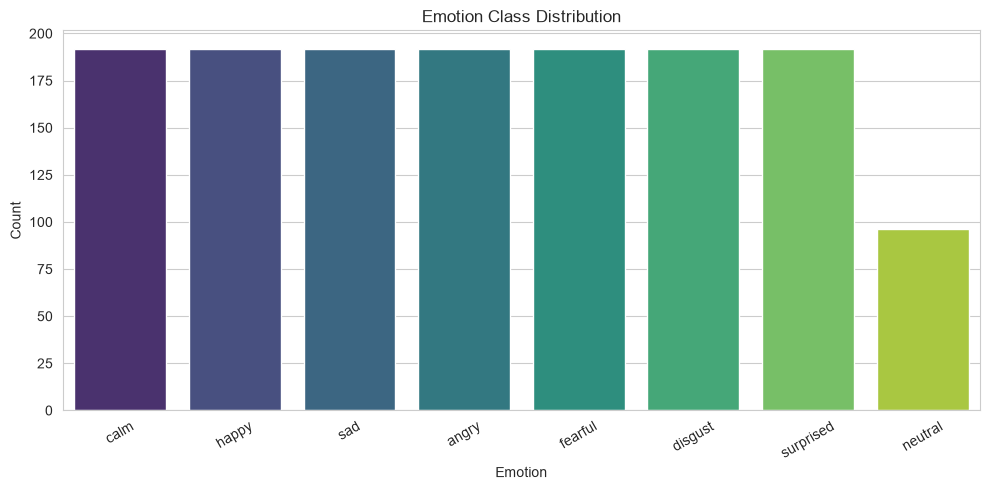

In [4]:
emotion_counts=df['emotion'].value_counts()
print(emotion_counts)

plt.figure()
sns.barplot(x=emotion_counts.index,y=emotion_counts.values,hue=emotion_counts.index,palette='viridis',legend=False)
plt.title('Emotion Class Distribution')
plt.ylabel('Count')
plt.xlabel('Emotion')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4.Actor & gender distribution

In [5]:
actor_counts=df['actor_id'].value_counts().sort_index()
print("Files per actor:")
print(actor_counts)

Files per actor:
actor_id
1     60
2     60
3     60
4     60
5     60
6     60
7     60
8     60
9     60
10    60
11    60
12    60
13    60
14    60
15    60
16    60
17    60
18    60
19    60
20    60
21    60
22    60
23    60
24    60
Name: count, dtype: int64


In [6]:
print("\nGender distribution:")
print(df['gender'].value_counts())


Gender distribution:
gender
male      720
female    720
Name: count, dtype: int64


## 5.Emotion balance PER actor

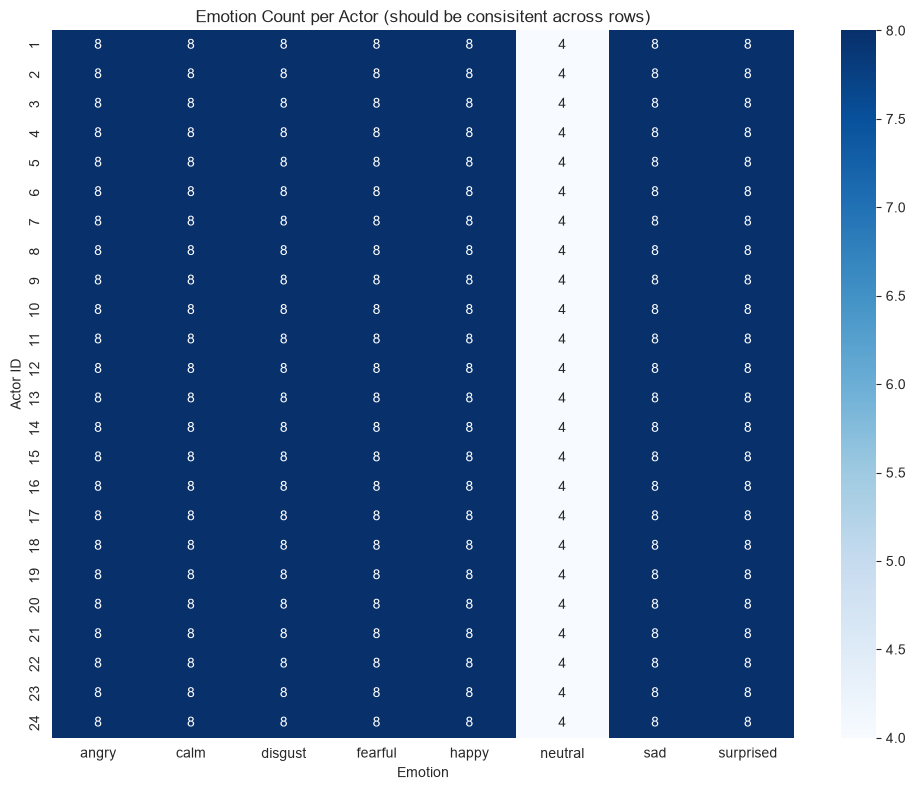

In [7]:
pivot=pd.crosstab(df['actor_id'],df['emotion'])
plt.figure(figsize=(10,8))
sns.heatmap(pivot,annot=True,fmt='d',cmap='Blues',cbar=True)
plt.title('Emotion Count per Actor (should be consisitent across rows)')
plt.xlabel('Emotion')
plt.ylabel('Actor ID')
plt.tight_layout()
plt.show()

## 6.Actor-independent split:class balance check

In [8]:
from sklearn.model_selection import train_test_split
from src.config import RANDOM_SEED,TEST_SIZE,VAL_SIZE

unique_actors=sorted(df['actor_id'].unique())
actor_gender=['male' if a %2!=0 else 'female' for a in unique_actors]

train_actors,temp_actors=train_test_split(
    unique_actors,test_size=(TEST_SIZE+VAL_SIZE),
    stratify=actor_gender,random_state=RANDOM_SEED)
temp_gender=['male' if a %2!=0 else 'female' for a in temp_actors]
test_relative=TEST_SIZE/(TEST_SIZE+VAL_SIZE)
val_actors,test_actors=train_test_split(
    temp_actors,test_size=test_relative,stratify=temp_gender,random_state=RANDOM_SEED
)
print("Train actors:", train_actors)
print("Val actors:  ", val_actors)
print("Test actors: ", test_actors)
 
split_df = df.copy()
split_df['split'] = np.select(
    [split_df['actor_id'].isin(train_actors),
     split_df['actor_id'].isin(val_actors),
     split_df['actor_id'].isin(test_actors)],
    ['train', 'val', 'test']
)
 
print("\nSamples per split:")
print(split_df['split'].value_counts())
 
print("\nEmotion distribution WITHIN each split (as %):")
split_emotion_pct = pd.crosstab(split_df['split'], split_df['emotion'], normalize='index') * 100
print(split_emotion_pct.round(1))

Train actors: [20, 7, 12, 1, 3, 24, 4, 18, 2, 22, 21, 9, 13, 6, 19, 17]
Val actors:   [5, 14]
Test actors:  [11, 10, 23, 15, 16, 8]

Samples per split:
split
train    960
test     360
val      120
Name: count, dtype: int64

Emotion distribution WITHIN each split (as %):
emotion  angry  calm  disgust  fearful  happy  neutral   sad  surprised
split                                                                  
test      13.3  13.3     13.3     13.3   13.3      6.7  13.3       13.3
train     13.3  13.3     13.3     13.3   13.3      6.7  13.3       13.3
val       13.3  13.3     13.3     13.3   13.3      6.7  13.3       13.3


# 7.Audio duration and sample rate check

Sampled 150 files
Native sample rates found: {48000}
Duration - min: 3.14s, max: 4.80s, mean: 3.74s, std: 0.35s


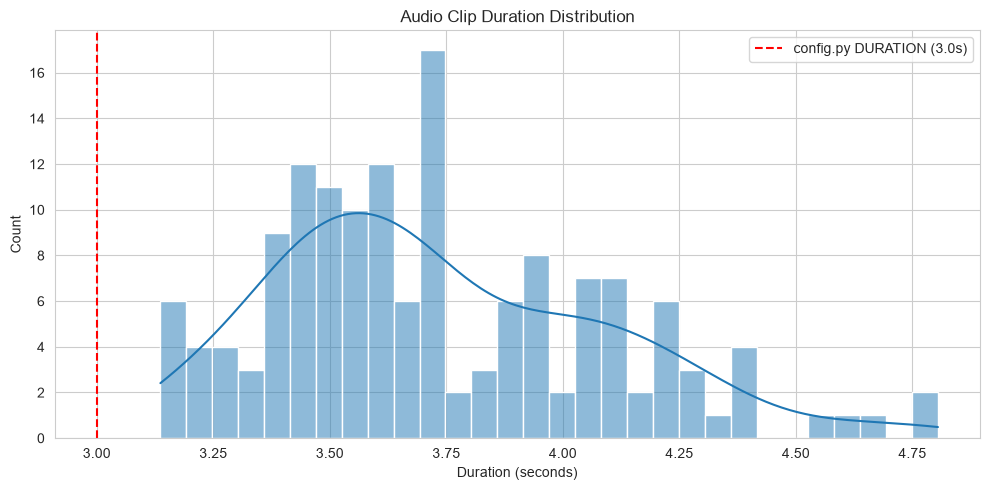

In [9]:
sample_files=df.sample(n=min(150,len(df)),random_state=RANDOM_SEED)['filepath'].tolist()

durations=[]
sample_rates=[]
for f in sample_files:
    try:
        sr_native = librosa.get_samplerate(f)
        dur = librosa.get_duration(path=f)
        durations.append(dur)
        sample_rates.append(sr_native)
    except Exception as e:
        print(f"[ERROR] {f}: {e}")
 
durations = np.array(durations)
print(f"Sampled {len(durations)} files")
print(f"Native sample rates found: {set(sample_rates)}")
print(f"Duration - min: {durations.min():.2f}s, max: {durations.max():.2f}s, "
      f"mean: {durations.mean():.2f}s, std: {durations.std():.2f}s")
 
plt.figure()
sns.histplot(durations, bins=30, kde=True)
plt.axvline(3.0, color='red', linestyle='--', label='config.py DURATION (3.0s)')
plt.title('Audio Clip Duration Distribution')
plt.xlabel('Duration (seconds)')
plt.legend()
plt.tight_layout()
plt.show()

## 8.Silence / low-energy file check

5 quietest files (potential silence/corruption):
                                              filepath       rms
121  C:\Users\mohit\Emotional Recognition from Spee...  0.001028
9    C:\Users\mohit\Emotional Recognition from Spee...  0.001115
83   C:\Users\mohit\Emotional Recognition from Spee...  0.001326
34   C:\Users\mohit\Emotional Recognition from Spee...  0.001345
1    C:\Users\mohit\Emotional Recognition from Spee...  0.001358


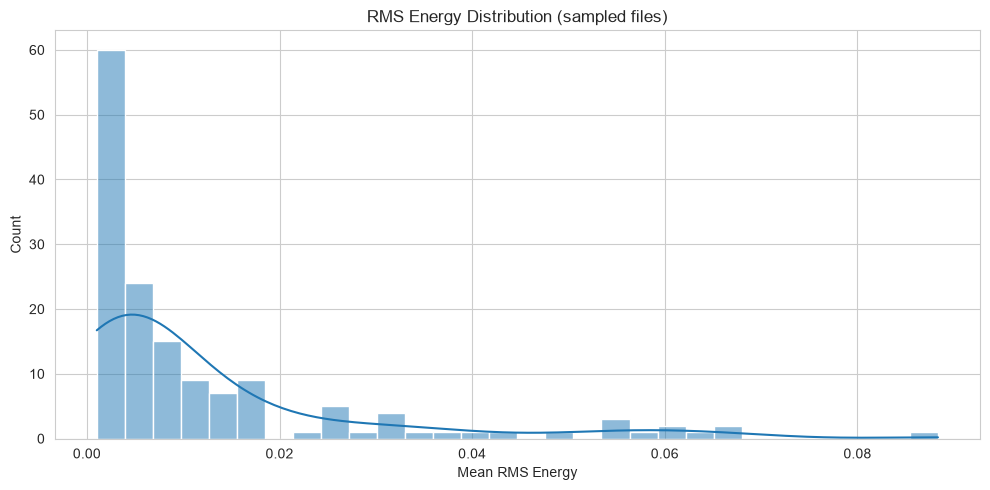

In [10]:
rms_values = []
for f in sample_files:
    try:
        y, sr = librosa.load(f, sr=SAMPLE_RATE)
        rms = np.mean(librosa.feature.rms(y=y))
        rms_values.append({'filepath': f, 'rms': rms})
    except Exception as e:
        print(f"[ERROR] {f}: {e}")
 
rms_df = pd.DataFrame(rms_values).sort_values('rms')
print("5 quietest files (potential silence/corruption):")
print(rms_df.head())
 
plt.figure()
sns.histplot(rms_df['rms'], bins=30, kde=True)
plt.title('RMS Energy Distribution (sampled files)')
plt.xlabel('Mean RMS Energy')
plt.tight_layout()
plt.show()

## 9.Waveform + Mel-Spectrogram per emotion

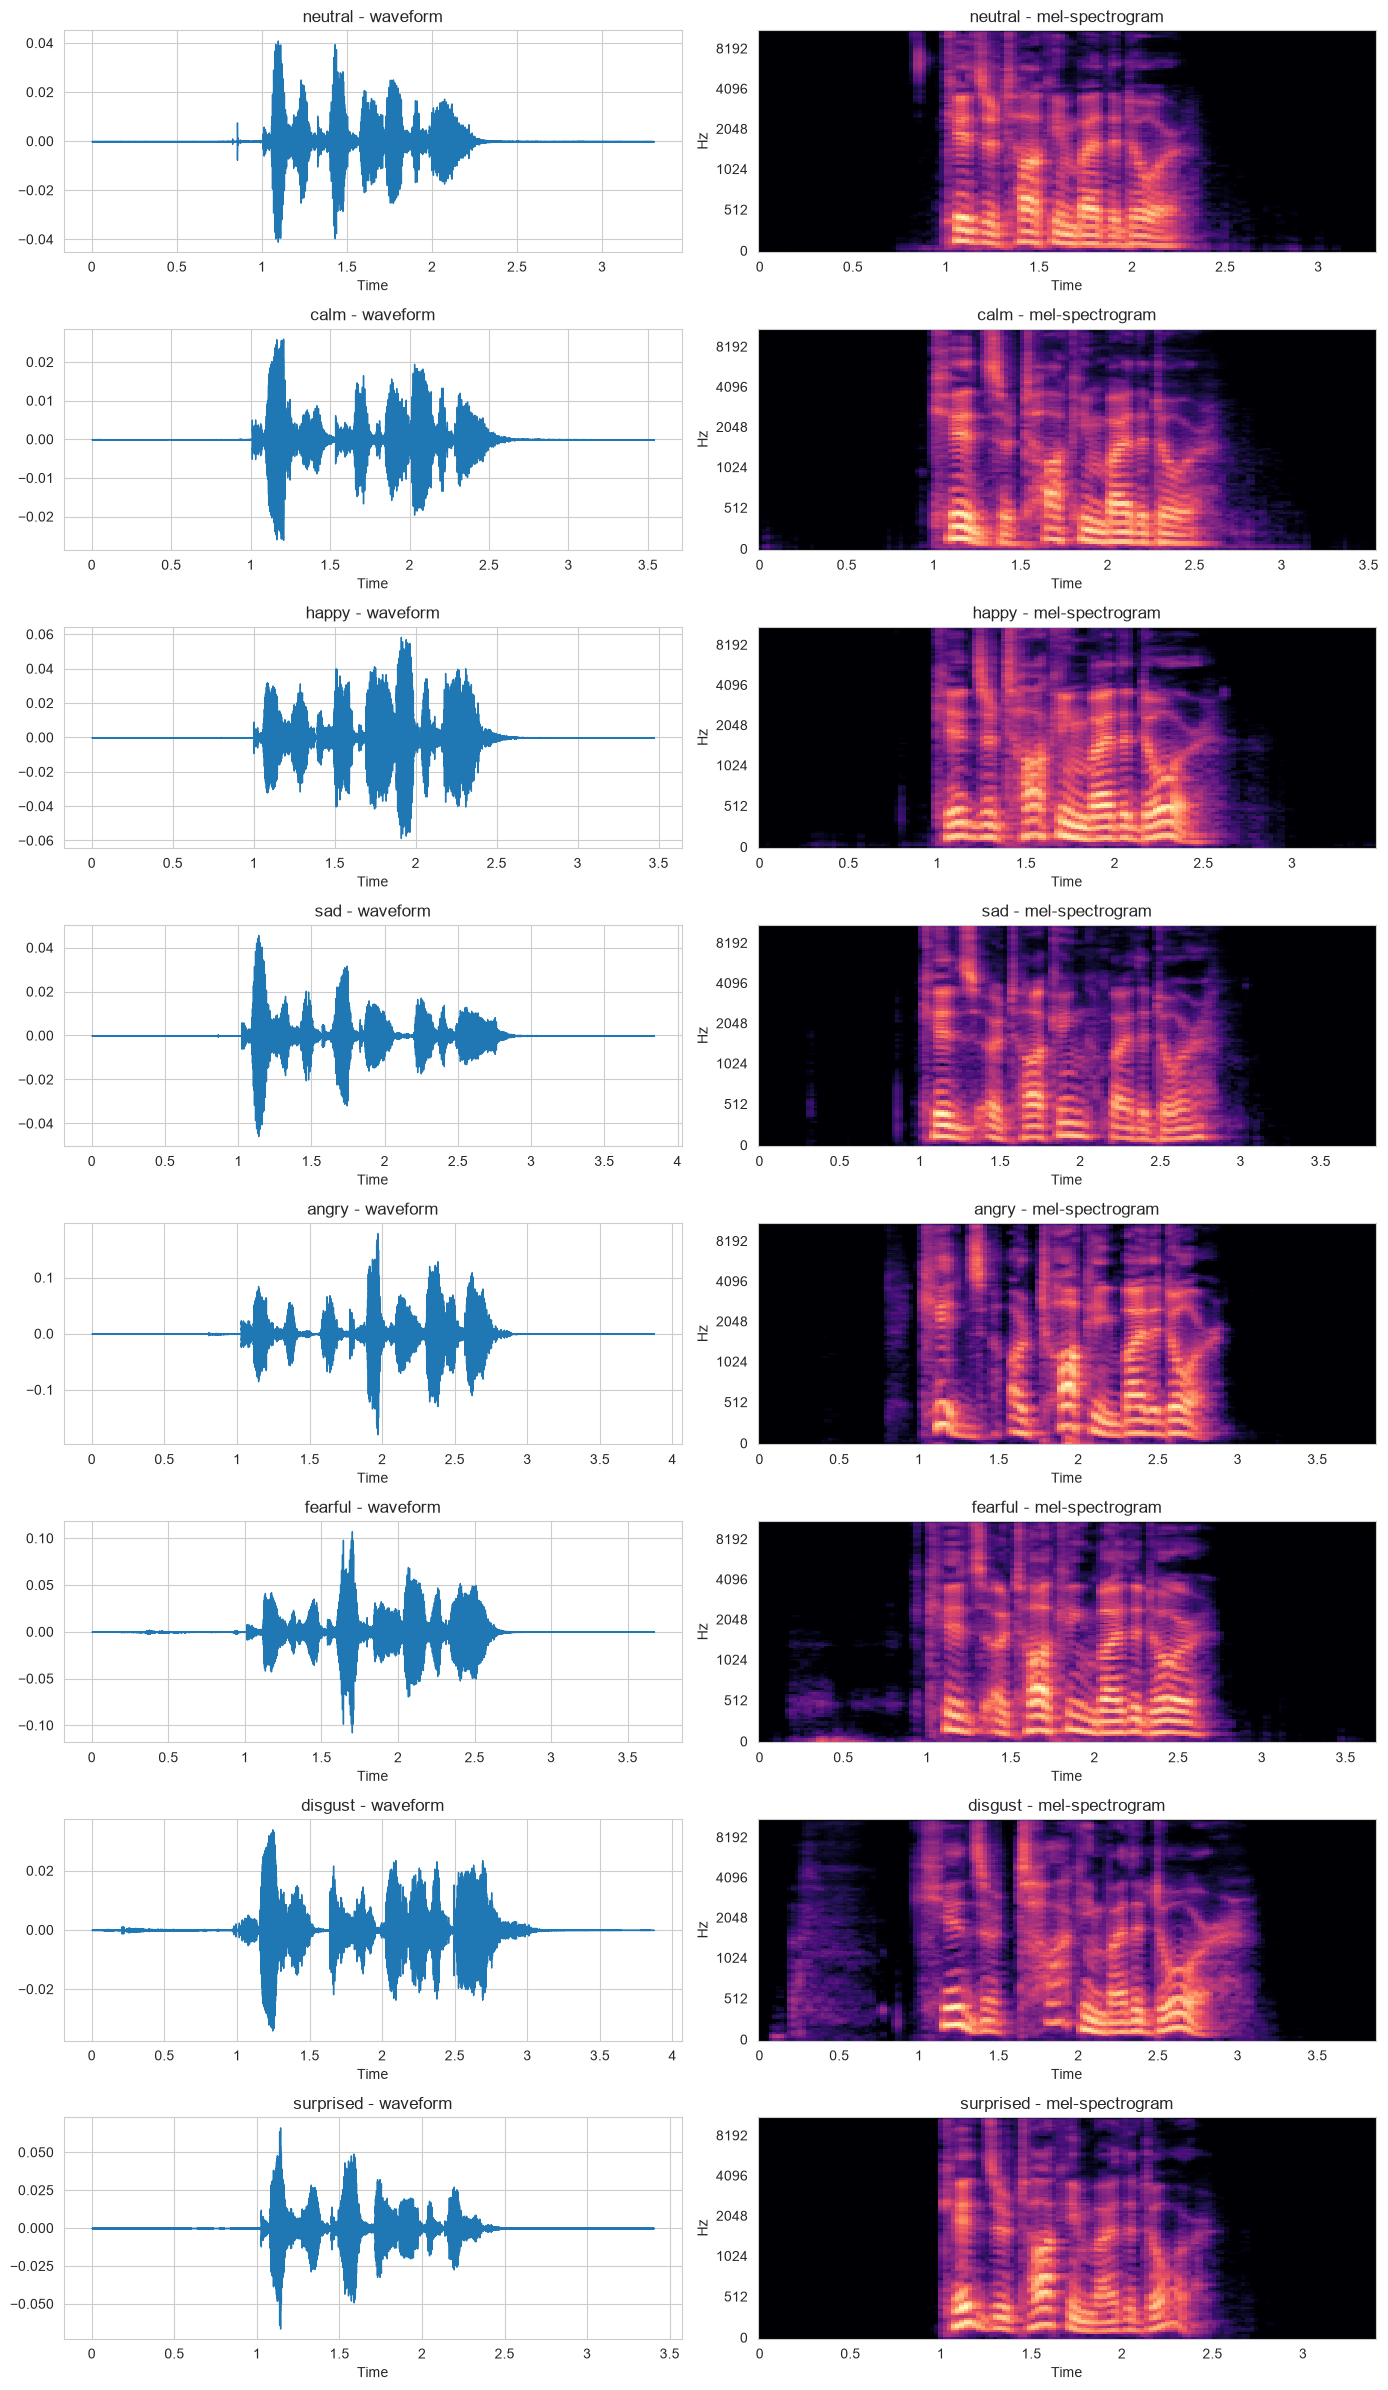

In [11]:
fig, axes = plt.subplots(len(EMOTION_MAP), 2, figsize=(14, 3*len(EMOTION_MAP)))
 
for i, (code_, emotion_name) in enumerate(EMOTION_MAP.items()):
    subset = df[df['emotion'] == emotion_name]
    if subset.empty:
        continue
    filepath = subset.iloc[0]['filepath']
    y, sr = librosa.load(filepath, sr=SAMPLE_RATE)
 
    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0])
    axes[i, 0].set_title(f'{emotion_name} - waveform')
 
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[i, 1])
    axes[i, 1].set_title(f'{emotion_name} - mel-spectrogram')
 
plt.tight_layout()
plt.show()